# Periodogram 

## This notebook aims to perform an analysis of the seasonal component of each time series for each patient.


For this purpose, we define our time series as follows 

$$

z_t = \sum_{t=1}^{T/2} A_j \sin(\omega_j t) + B_j \cos(\omega_j t)

$$



The upper limit of the summation is determined by the definition of the seasonal periods $s_j$. Specifically, we define:
$$
s_j = \frac{T}{j}, \quad \text{for } j = 1, 2, \dots, \left\lfloor \frac{T}{2} \right\rfloor,
$$
which implies that the set of possible seasonal periods is:
$$
s = \{2, 3, \dots, T\}.
$$

From this, we can derive bounds on the corresponding seasonal frequencies $f_j = 1/s_j$. Since $2 \leq s_j \leq T$, it follows that:
$$
\frac{1}{T} \leq f_j \leq \frac{1}{2}.
$$



In this way we can compute all coefficients $$ A_j $$ and $$ B_j $$ for all basic frequencies as the first equation establish. As we're interested at the waves with high amplitudes, we use a function of the frequency to discover those amplitudes, we compute it as follows:

$$
I(f_j) = \frac{T}{2} \, \hat{R}_j^2,
$$

Where:

$$
    \hat{R_j}^2 = \hat{A_j}^2 + \hat{B_j}^2
$$

And :

$$
\hat{A}_j = \frac{2}{T} \sum_{t=1}^{T} z_t \sin(\omega_j t), \qquad
\hat{B}_j = \frac{2}{T} \sum_{t=1}^{T} z_t \cos(\omega_j t),
$$

with $\omega_j = 2\pi f_j = \frac{2\pi j}{T}$ for $j = 1, \dots, \lfloor T/2 \rfloor$.

In [65]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 

In [66]:
def compute_coefficients(zt, frequencies):
    T = len(zt)
    t = np.arange(T)
    
    omega_t = 2 * np.pi * frequencies.reshape(-1, 1) * t
    
    a_j = (2/T) * np.sum(zt.values * np.sin(omega_t), axis=1)
    b_j = (2/T) * np.sum(zt.values * np.cos(omega_t), axis=1)
    
    return a_j, b_j

In [67]:
def periodogram(zt):
    T = len(zt)
    num_freq = T//2 + 1
    frequencies = np.linspace(1/T, 0.1, num=num_freq, dtype=np.float32)
    
    a_j, b_j = compute_coefficients(zt, frequencies)
    periodogram = (T/2) * (np.square(a_j) + np.square(b_j))
    return dict(zip(frequencies, periodogram))

In [68]:
def plot_periodogram(zt):
    T = len(zt)
    I_f = periodogram(zt)
    
    plt.figure(figsize=(12, 6))
    plt.plot(I_f.keys(), I_f.values())
    plt.xlabel('Frequency')
    plt.ylabel('Amplitude')
    plt.title('Periodogram')
    plt.grid(True)
    plt.show()

Now, let's read all patients and plot the periodogram 

In [69]:
import os 

data_dir = '../Data/Preprocessed'
base_paths = os.listdir(data_dir)
full_paths = [os.path.join(data_dir, p) for p in base_paths]

In [70]:
def cast_to_time(df):
    df['time'] = pd.to_datetime(df['time'])
    return df

In [71]:
patients = {base_paths[i].split('.')[0] : cast_to_time(pd.read_csv(fp, sep=';')) for i, fp in enumerate(full_paths)}

In [72]:
def create_two_plots(two_series_dictionary):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    i = 0
    for key, value in two_series_dictionary.items():
        ax_i = axes[i]
        periodogram_i = periodogram(value['glucose'])
        ax_i.plot(periodogram_i.keys(), list(periodogram_i.values()))
        ax_i.set(title = key)
        ax_i.set_xlim((0, 0.006))
        ax_i.grid()
        i += 1
    plt.tight_layout()
    plt.show()


In [73]:
import gc

In [74]:
def plot_periodograms(keys, patients):
    num_patients = len(keys)
    print(num_patients)
    i = 0
    j = 1
    while j < num_patients:
        key_1 = keys[i]
        key_2 = keys[j]
        temp_dict = {key_1 : patients[key_1], key_2 : patients[key_2]}
        create_two_plots(temp_dict)
        plt.close('all')  
        del temp_dict     
        gc.collect()     
        i += 2
        j = i + 1

In [75]:
keys = list(patients.keys())[:-3]

12


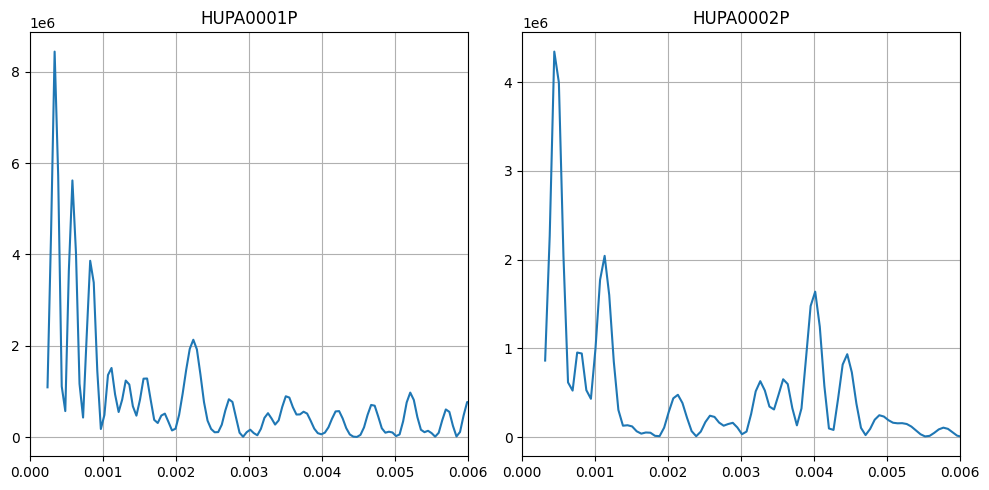

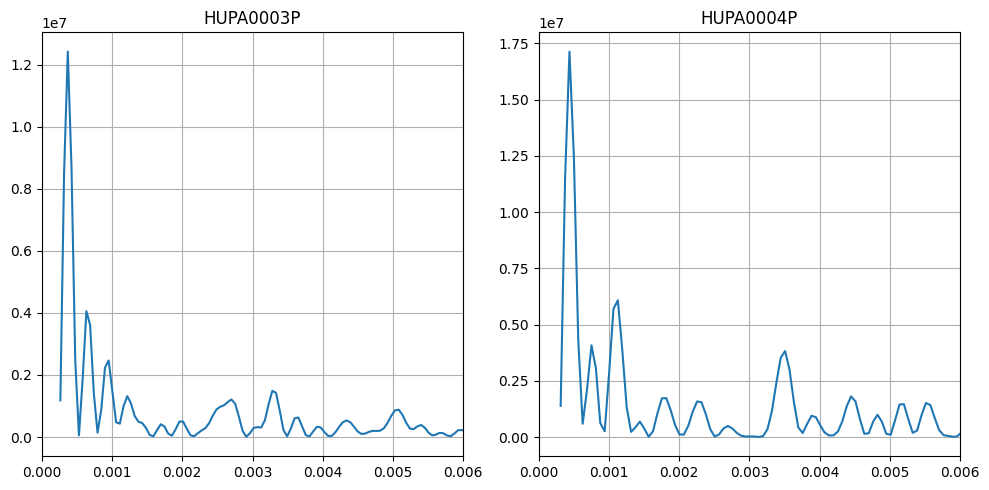

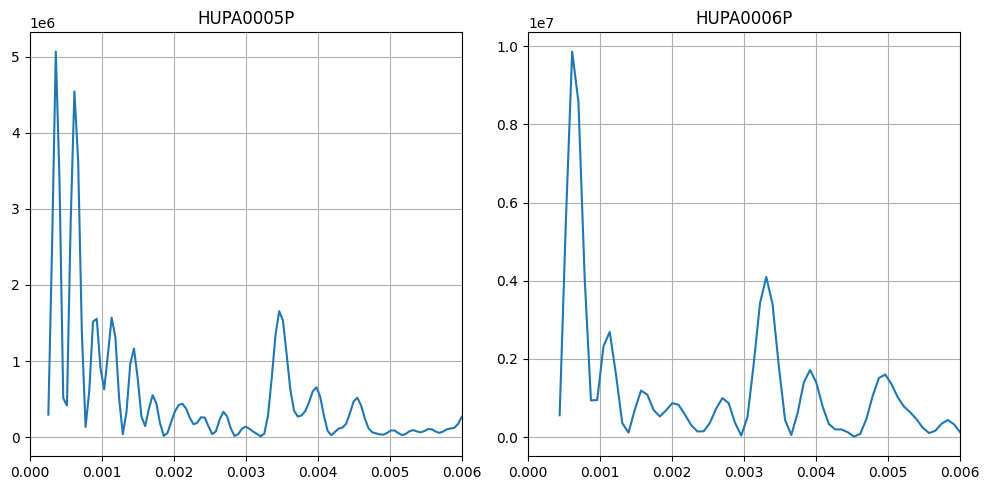

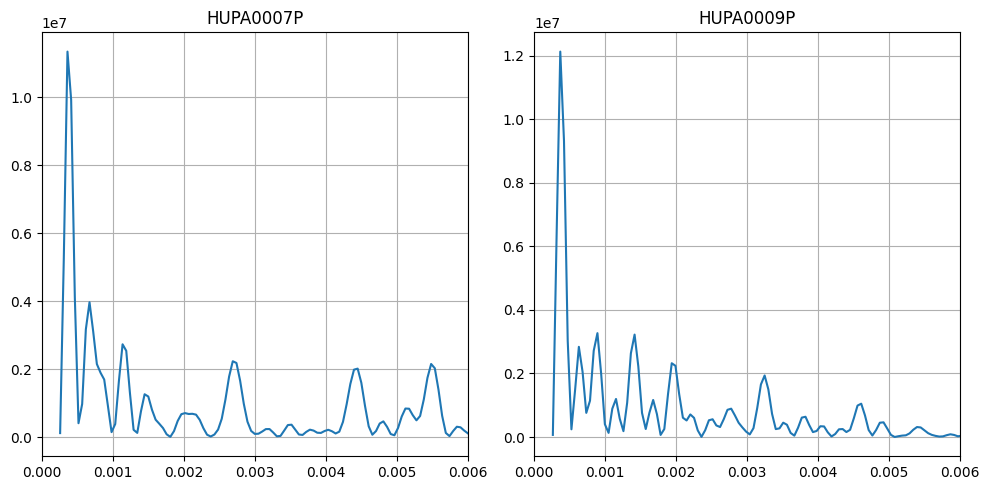

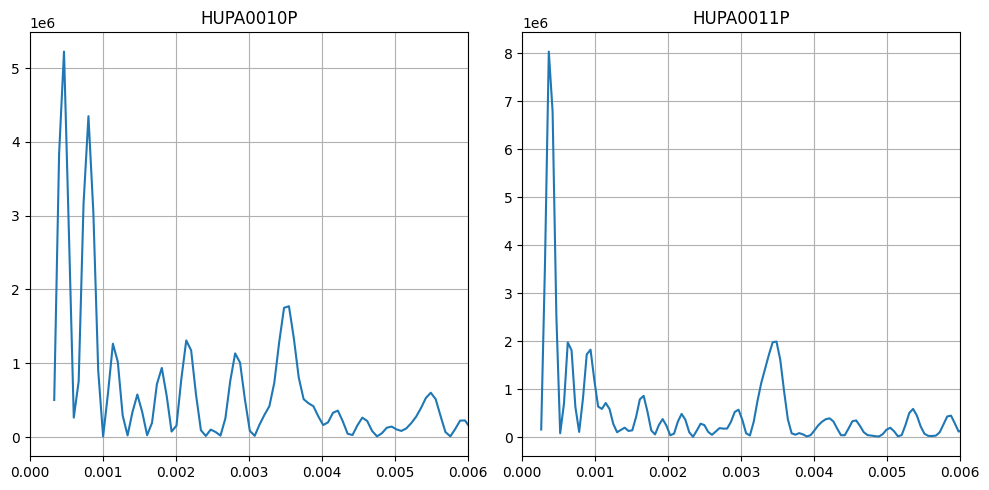

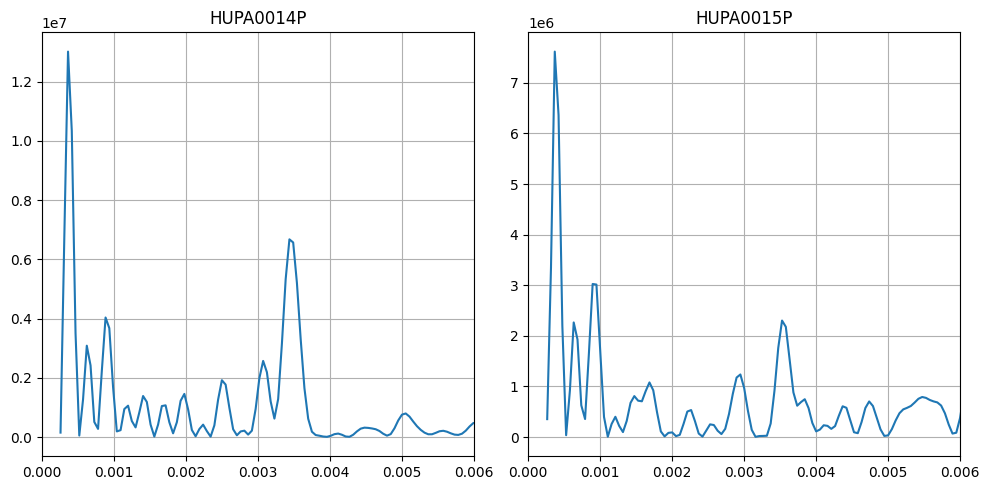

In [76]:
plot_periodograms(keys[:12], patients)

10


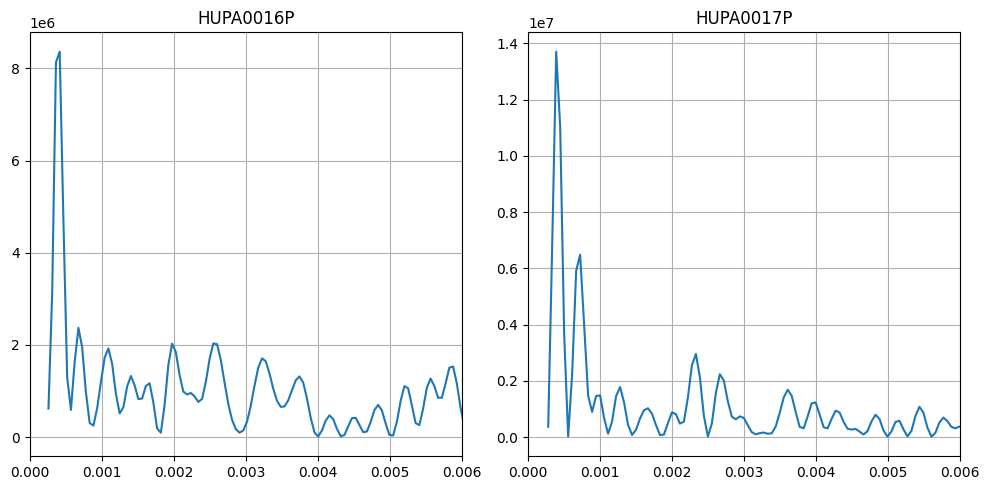

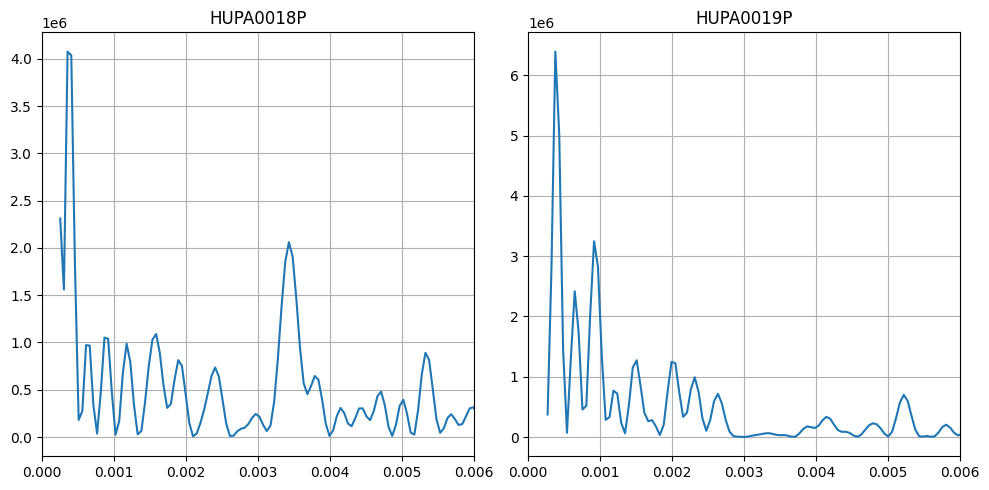

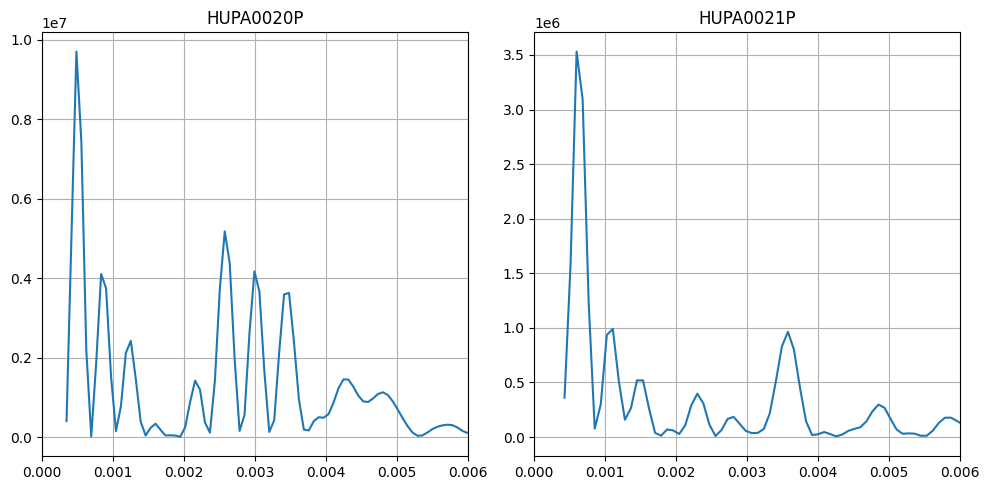

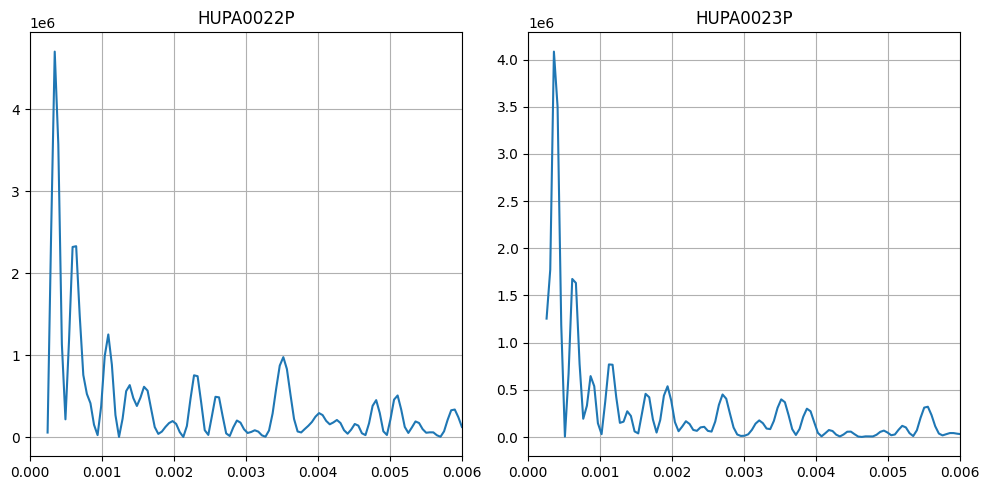

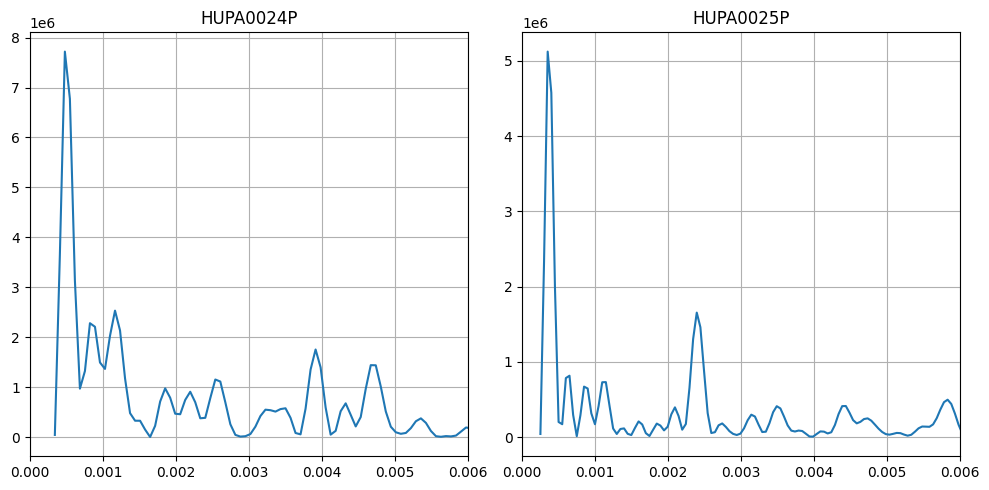

In [77]:
plot_periodograms(keys[12:], patients)

In [78]:
def get_season(x):
    return [1/x[0], x[1]]

In [79]:
top_frequencies_all_patients = {key:list(map(get_season, sorted(periodogram(patients[key]['glucose']).items(), key=lambda x : x[1], reverse=True)))[:5] for key in keys}

In [80]:
top_frequencies_all_patients

{'HUPA0001P': [[np.float32(2927.7566), np.float64(8441143.901844129)],
  [np.float32(2562.346), np.float64(5723187.142008692)],
  [np.float32(1709.1006), np.float64(5619233.5969217)],
  [np.float32(3414.7227), np.float64(4470953.2619274445)],
  [np.float32(1577.7551), np.float64(4037048.8696889826)]],
 'HUPA0002P': [[np.float32(2273.9817), np.float64(4343154.015515486)],
  [np.float32(1990.2372), np.float64(3994824.0257837223)],
  [np.float32(2652.0842), np.float64(2266911.663036932)],
  [np.float32(1769.448), np.float64(2042285.460892821)],
  [np.float32(885.42096), np.float64(2041503.4023281296)]],
 'HUPA0003P': [[np.float32(2694.8994), np.float64(12417402.738529399)],
  [np.float32(2358.5962), np.float64(8651772.44840429)],
  [np.float32(3143.0562), np.float64(8495164.814945683)],
  [np.float32(1573.2677), np.float64(4053251.1990284864)],
  [np.float32(1452.3707), np.float64(3609164.6299245344)]],
 'HUPA0004P': [[np.float32(2276.3284), np.float64(17129436.052711364)],
  [np.float32(